# Averted-Cost Auditing of SAE Feature Absorption — Demo

**Artifact:** *M1′′′′′ Averted-Cost Auditing Scenario* (`method.py`).

A practitioner ships two downstream artifacts built on frozen **Gemma-Scope L12/16k** JumpReLU SAE
latents over **gemma-2-2b** — a parent-concept **classifier** and a parent-concept **steering
handle** — both selected by SAEBench **SCR/TPP marginal-attribution** (the standard raw-latent
practice). Because of **feature absorption**, the latent that carries a specific slice (e.g. the
country *Georgia*, the org *Amazon*) is silently dropped from the compact top-N selection, so the
shipped artifact has a **recall / steer hole** on that slice. The shipped label-free firing-signature
**screen** *catches* the hole and *names* the absorber with zero sub-context labels, and adding that
one named latent **repairs** the compact unit.

The end-to-end chain per arm:

| step | evidence |
|------|----------|
| **(a) silent failure** | absorbed-slice recall/steer ≪ sibling-slice (gap CI excl 0) |
| **(b) standard practice misses it** | absorber buried deep in the SCR/TPP ranking (Georgia rank 42, Amazon rank 14) and the decoder-projection oracle scores Georgia *clean* |
| **(c) the screen catches it** | flags `ABSORPTION_STRUCTURED` + names the latent |
| **(d) named-absorber repair** | adding it lifts the compact unit (KG−baseline CI excl 0), negligible sibling collateral |

Per-arm FORK verdict: **`AVERTED_COST_DEMONSTRATED`** else the matching honest null.

---
### What this demo runs
The **model-internal core** (loading gemma-2-2b + the Gemma-Scope SAE, ~12 GB GPU, ~450 s) is
**precomputed** and shipped as `method_out.json`. This notebook loads that result and reproduces the
**`$0` analysis layer** of `method.py` **verbatim**:
1. the two-sample / paired **bootstrap CIs** (`two_sample_bootstrap_diff`, `paired_bootstrap_diff`),
2. the per-arm **FORK verdict** logic (`classify_arm`),

then visualises the silent hole, the N-curve at which it closes, and the named-absorber repair.
No GPU, no model download — it runs in seconds on CPU.

In [1]:
# --- Install dependencies (works on both Colab and a local/clean Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab (with linked C extensions); installing them on
# Colab corrupts those extensions. So only install locally, pinned to Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The demo's analysis layer only needs `numpy` (the bootstrap engine) + `matplotlib` for plots,
plus `json`/`Counter` exactly as in the original `method.py` import block.

In [2]:
import os, json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

## Load the precomputed results
`mini_demo_data.json` is a curated subset of the artifact's `method_out.json`: the full
`averted_cost_table` (all 4 arms) plus the two output datasets. We fetch it from GitHub, with a
local-file fallback so the notebook also runs offline next to the data file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-10/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
md_ = data["metadata"]
table = md_["averted_cost_table"]          # the 4 arms the analysis layer runs on

print(f"method     : {md_['method_name']}")
print(f"SAE        : {md_['sae']['release']}  {md_['sae']['sae_id']}")
print(f"model      : {md_['model']}")
print(f"overall    : {md_['overall_verdict']}")
print(f"arms       : {[e['scenario'] for e in table]}")
print(f"per-arm    : {json.dumps(md_['per_arm_fork'], indent=0)}")

method     : M1''''' Averted-Cost Auditing Scenario
SAE        : google/gemma-scope-2b-pt-res  layer_12/width_16k/average_l0_82/params.npz
model      : google/gemma-2-2b
overall    : AVERTED_COST_DEMONSTRATED
arms       : ['georgia_classifier', 'amazon_classifier', 'amazon_steer', 'large_steer']
per-arm    : {
"georgia_classifier": "AVERTED_COST_DEMONSTRATED",
"amazon_classifier": "AVERTED_COST_DEMONSTRATED",
"amazon_steer": "AVERTED_COST_DEMONSTRATED",
"large_steer": "HN_SCREEN_DESCRIPTIVE_ONLY"
}


## Config
All tunable parameters live here. The only knob that affects runtime is `B_BOOT`, the number of
bootstrap resamples. The original run used **10000**; we start small and scale up — the reproduced
CIs converge to the stored ones as `B_BOOT` grows.

`rng`, `B_BOOT`, `N_GRID`, `HEADLINE_N` mirror the module-level constants in `method.py`.

In [5]:
SEED       = 1234                  # core.SEED
B_BOOT     = 10000                 # bootstrap resamples. ORIGINAL: 10000 (cheap on CPU; see scaling note)
N_GRID     = (1, 2, 5, 10, 20)     # SAEBench SCR/TPP selection-size grid (method.N_GRID)
HEADLINE_N = 5                     # compact, human-auditable classifier/steer size (method.HEADLINE_N)

# module-level rng used by the (verbatim) bootstrap functions, exactly as in method.py
rng = np.random.default_rng(SEED)
print(f"B_BOOT={B_BOOT}  SEED={SEED}  N_GRID={N_GRID}  HEADLINE_N={HEADLINE_N}")

B_BOOT=10000  SEED=1234  N_GRID=(1, 2, 5, 10, 20)  HEADLINE_N=5


## The bootstrap engine (copied verbatim from `method.py` / `core.py`)
`two_sample_bootstrap_diff` (unpaired, for the silent-failure gap between different slices) and
`paired_bootstrap_diff` (paired, for the repair / collateral on the *same* rows). Both reference the
module-level `rng` and `B_BOOT` defined above — unchanged from the original sources.

In [6]:
def two_sample_bootstrap_diff(a, b, B=B_BOOT):
    """UNPAIRED bootstrap of mean(a)-mean(b) (slices are different rows). a,b: 1-D arrays."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    na, nb = len(a), len(b)
    out = {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n_a": int(na), "n_b": int(nb),
           "mean_a": float(a.mean()) if na else 0.0, "mean_b": float(b.mean()) if nb else 0.0}
    if na == 0 or nb == 0:
        return out
    ia = rng.integers(0, na, size=(B, na)); ib = rng.integers(0, nb, size=(B, nb))
    d = a[ia].mean(1) - b[ib].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    out.update({"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
                "excl_0": bool(lo > 0 or hi < 0)})
    return out


def paired_bootstrap_diff(a, b, B=B_BOOT):
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}

## (a) Reproduce the *silent-failure gap* CI
The classifier metric is a **binary per-row recall** (0/1), so from the stored `(mean, n)` of each
slice we can reconstruct an equivalent 0/1 vector and re-run `two_sample_bootstrap_diff`. The
two-sample bootstrap of a binary array depends only on `(#ones, n)`, so this faithfully reproduces
the stored sibling-minus-absorbed gap CI (up to Monte-Carlo noise that shrinks with `B_BOOT`).

In [7]:
def reconstruct_binary(mean, n):
    "0/1 recall vector of length n with round(mean*n) ones (faithful for the binary classifier metric)."
    n = int(n); k = int(round(float(mean) * n))
    v = np.zeros(n, dtype=np.float32); v[:k] = 1.0
    return v

print(f"{'arm':<20}{'stored gap [lo, hi]':<28}{'reproduced gap [lo, hi]':<28}{'|Δdiff|':>9}")
print("-" * 85)
for entry in table:
    if entry["arm_type"] != "classifier":
        continue
    g = entry["silent_failure_gap"]                       # headline-N (=5) gap, sibling - absorbed
    sib = reconstruct_binary(g["mean_a"], g["n_a"])       # sibling-slice recalls
    ab  = reconstruct_binary(g["mean_b"], g["n_b"])       # absorbed-slice recalls
    repro = two_sample_bootstrap_diff(sib, ab)
    print(f"{entry['scenario']:<20}"
          f"{g['diff']:.3f} [{g['ci_lo']:.3f}, {g['ci_hi']:.3f}]   "
          f"{repro['diff']:.3f} [{repro['ci_lo']:.3f}, {repro['ci_hi']:.3f}]   "
          f"{abs(g['diff']-repro['diff']):>9.4f}")

arm                 stored gap [lo, hi]         reproduced gap [lo, hi]       |Δdiff|
-------------------------------------------------------------------------------------


georgia_classifier  0.862 [0.809, 0.910]   0.862 [0.810, 0.909]      0.0000
amazon_classifier   0.673 [0.613, 0.728]   0.673 [0.613, 0.728]      0.0000


## (d) Reproduce the *named-absorber repair* CI (paired)
Same idea, paired on the absorbed-slice rows: reconstruct the repaired vs. baseline 0/1 recalls and
re-run `paired_bootstrap_diff`. At the compact headline size the repaired recall is `1.0`, so the
reconstruction is exact and the CI matches the stored `kg_minus_baseline`.

In [8]:
print(f"{'arm':<20}{'stored repair [lo, hi]':<30}{'reproduced repair [lo, hi]':<30}")
print("-" * 80)
for entry in table:
    if entry["arm_type"] != "classifier":
        continue
    rep = entry["kg_minus_baseline"]; n = rep["n"]
    repaired = reconstruct_binary(entry["repaired_absorbed_metric"], n)   # ~1.0 at headline N
    baseline = reconstruct_binary(entry["baseline_absorbed_metric"], n)   # the silent hole
    repro = paired_bootstrap_diff(repaired, baseline)
    print(f"{entry['scenario']:<20}"
          f"{rep['diff']:.3f} [{rep['ci_lo']:.3f}, {rep['ci_hi']:.3f}]      "
          f"{repro['diff']:.3f} [{repro['ci_lo']:.3f}, {repro['ci_hi']:.3f}]")

arm                 stored repair [lo, hi]        reproduced repair [lo, hi]    
--------------------------------------------------------------------------------
georgia_classifier  0.893 [0.840, 0.940]      0.893 [0.840, 0.940]
amazon_classifier   0.913 [0.867, 0.953]      0.913 [0.867, 0.953]


## The per-arm FORK verdict (copied verbatim from `method.py`)
`classify_arm` is the decision rule: an arm is `AVERTED_COST_DEMONSTRATED` iff the hole is real
(CI excl 0) **and** standard practice missed it (absorber not in top-N) **and** the screen flagged +
named it **and** the repair CI excludes 0 **and** sibling collateral stays within tolerance — else the
matching honest null. It operates purely on the stored CI dicts, so we can reproduce every arm's
verdict from the loaded table.

In [9]:
def classify_arm(silent, in_topN, flags, repair, collat, collat_tol=0.02):
    # collat_tol: a sibling degradation is only disqualifying if it is BOTH significant (CI excl 0) AND
    # larger than collat_tol in magnitude -- with large sibling-n a 0.2% change is CI-significant but
    # practically negligible; we report it but do not let it veto a clean repair.
    hole_real = bool(silent.get("excl_0") and silent.get("diff", 0) > 0)
    miss = bool(not in_topN)
    screen_catches = bool(flags.get("predict_absorption") == "ABSORPTION_STRUCTURED"
                          and flags.get("named_absorber") is not None)
    repaired = bool(repair.get("excl_0") and repair.get("diff", 0) > 0)
    no_collat = not bool(collat.get("excl_0") and collat.get("diff", 0) < -abs(collat_tol))
    if hole_real and miss and screen_catches and repaired and no_collat:
        return "AVERTED_COST_DEMONSTRATED"
    if not hole_real:
        return "HN_NO_HOLE"
    if not screen_catches:
        # the screen DECLINED to STRICT-certify a low-data slice (n_eligible<150) -> not a miss, a
        # conservative abstention; the hole+repair mechanism may still be present (reported in the table).
        if flags.get("predict_absorption") == "DESCRIPTIVE_ONLY" or flags.get("eligible") is False:
            return "HN_SCREEN_DESCRIPTIVE_ONLY"
        return "HN_SCREEN_MISS"
    if not repaired:
        return "HN_REPAIR_NULL"
    if not no_collat:
        return "HN_SIBLING_COLLATERAL"
    return "HN_NO_HOLE"

In [10]:
print(f"{'arm':<20}{'reproduced verdict':<34}{'stored verdict':<34}{'match'}")
print("-" * 95)
all_match = True
for entry in table:
    sc = entry["screen_catch"]
    flags = {"predict_absorption": sc["predict_absorption"], "named_absorber": sc.get("named_absorber")}
    verdict = classify_arm(
        entry["silent_failure_gap"],
        entry["standard_practice_miss"]["in_topN"],
        flags,
        entry["kg_minus_baseline"],
        entry["sibling_collateral"],
        collat_tol=entry["collat_tol"],
    )
    ok = (verdict == entry["arm_fork_verdict"])
    all_match &= ok
    print(f"{entry['scenario']:<20}{verdict:<34}{entry['arm_fork_verdict']:<34}{'OK' if ok else 'MISMATCH'}")
print("-" * 95)
print(f"all arms reproduced exactly: {all_match}")

arm                 reproduced verdict                stored verdict                    match
-----------------------------------------------------------------------------------------------
georgia_classifier  AVERTED_COST_DEMONSTRATED         AVERTED_COST_DEMONSTRATED         OK
amazon_classifier   AVERTED_COST_DEMONSTRATED         AVERTED_COST_DEMONSTRATED         OK
amazon_steer        AVERTED_COST_DEMONSTRATED         AVERTED_COST_DEMONSTRATED         OK
large_steer         HN_SCREEN_DESCRIPTIVE_ONLY        HN_SCREEN_DESCRIPTIVE_ONLY        OK
-----------------------------------------------------------------------------------------------
all arms reproduced exactly: True


## The N-curve: where does the hole close?
The averted cost is **N-dependent**. At compact, human-auditable sizes (`k≤5`) the absorbed slice is
silently missed; a larger, less-auditable raw-latent ensemble (`k≥10`) dilutes the hole on its own.
So the cost is the **lost auditability** (more latents) or the **shipped hole** — *not* a permanent
information loss. We print each classifier arm's per-N recall curve and the `hole_closes_at_N`.

In [11]:
for entry in table:
    if entry["arm_type"] != "classifier":
        continue
    print(f"\n=== {entry['scenario']}  (hole_closes_at_N = {entry['hole_closes_at_N']}) ===")
    print(f"{'N':>4}{'base_absorbed':>16}{'base_sibling':>16}{'repaired_absorbed':>20}{'gap_excl0':>12}")
    for N in N_GRID:
        d = entry["by_N"][str(N)]
        print(f"{N:>4}{d['baseline_absorbed_recall']:>16.3f}{d['baseline_sibling_recall']:>16.3f}"
              f"{d['repaired_absorbed_recall']:>20.3f}{str(d['silent_failure_gap']['excl_0']):>12}")


=== georgia_classifier  (hole_closes_at_N = 10) ===
   N   base_absorbed    base_sibling   repaired_absorbed   gap_excl0
   1           0.193           0.959               1.000        True
   2           0.180           0.961               1.000        True
   5           0.107           0.969               1.000        True
  10           0.993           0.968               1.000        True
  20           0.993           0.991               1.000       False

=== amazon_classifier  (hole_closes_at_N = 10) ===
   N   base_absorbed    base_sibling   repaired_absorbed   gap_excl0
   1           0.007           0.507               1.000        True
   2           0.093           0.717               1.000        True
   5           0.087           0.760               1.000        True
  10           1.000           0.985               1.000        True
  20           1.000           0.997               1.000       False


## Visualisation
- **Top row** — the N-curve for each classifier arm: the absorbed-slice recall (red) collapses far
  below the sibling recall (grey) at small N and recovers once the named absorber is added (green);
  the dashed line marks where the raw-latent ensemble dilutes the hole on its own.
- **Bottom row** — the headline-N silent hole + repair, for the classifier arms (recall units) and the
  steer arms (probe-margin-drop units): absorbed baseline ≪ sibling baseline, repaired ≈ recovered.

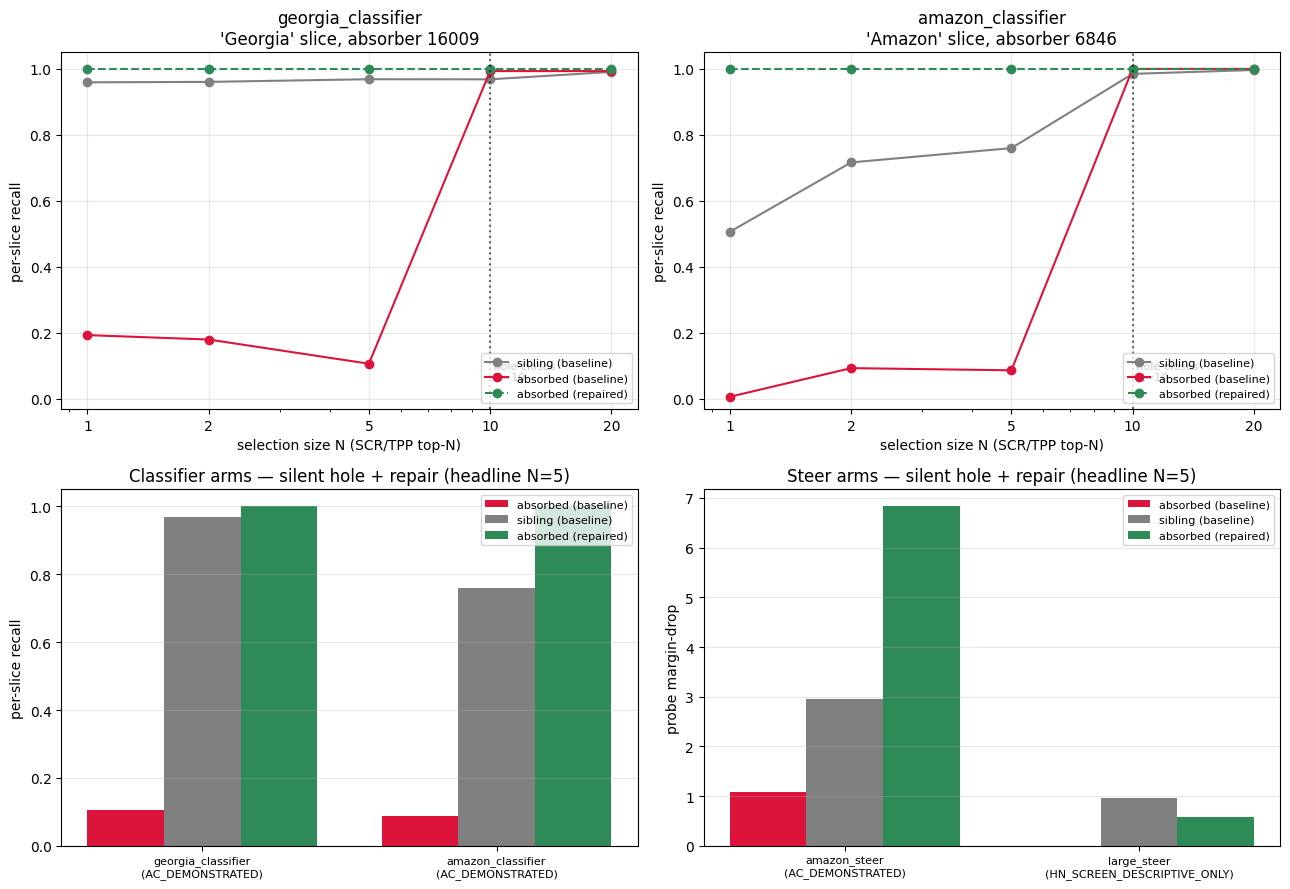

In [12]:
classifiers = [e for e in table if e["arm_type"] == "classifier"]
steers      = [e for e in table if e["arm_type"] == "steer"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- top row: N-curves for the two classifier arms ---
for ax, entry in zip(axes[0], classifiers):
    Ns = list(N_GRID)
    base_abs = [entry["by_N"][str(N)]["baseline_absorbed_recall"] for N in Ns]
    base_sib = [entry["by_N"][str(N)]["baseline_sibling_recall"] for N in Ns]
    rep_abs  = [entry["by_N"][str(N)]["repaired_absorbed_recall"] for N in Ns]
    ax.plot(Ns, base_sib, "o-", color="grey",      label="sibling (baseline)")
    ax.plot(Ns, base_abs, "o-", color="crimson",   label="absorbed (baseline)")
    ax.plot(Ns, rep_abs,  "o--", color="seagreen", label="absorbed (repaired)")
    hc = entry["hole_closes_at_N"]
    if hc is not None:
        ax.axvline(hc, ls=":", color="black", alpha=.6)
        ax.text(hc, 0.05, f" hole closes\n N={hc}", fontsize=8, va="bottom")
    ax.set_xscale("log"); ax.set_xticks(Ns); ax.set_xticklabels(Ns)
    ax.set_xlabel("selection size N (SCR/TPP top-N)"); ax.set_ylabel("per-slice recall")
    ax.set_ylim(-0.03, 1.05)
    ax.set_title(f"{entry['scenario']}\n'{entry['absorbed_slice']}' slice, absorber {entry['absorber_latent']}")
    ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=.3)

# --- bottom row: headline-N silent hole + repair (classifier recall | steer margin-drop) ---
def _bar_panel(ax, entries, ylabel, title):
    labels, abs_b, sib_b, abs_r = [], [], [], []
    for e in entries:
        labels.append(f"{e['scenario']}\n({e['arm_fork_verdict'].replace('AVERTED_COST_','AC_')})")
        abs_b.append(e["baseline_absorbed_metric"]); sib_b.append(e["baseline_sibling_metric"])
        abs_r.append(e["repaired_absorbed_metric"])
    x = np.arange(len(labels)); w = 0.26
    ax.bar(x - w, abs_b, w, color="crimson",   label="absorbed (baseline)")
    ax.bar(x,     sib_b, w, color="grey",       label="sibling (baseline)")
    ax.bar(x + w, abs_r, w, color="seagreen",   label="absorbed (repaired)")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

_bar_panel(axes[1][0], classifiers, "per-slice recall", "Classifier arms — silent hole + repair (headline N=5)")
_bar_panel(axes[1][1], steers,      "probe margin-drop", "Steer arms — silent hole + repair (headline N=5)")

plt.tight_layout(); plt.show()

## Summary table
One row per arm: the silent-failure gap, the standard-practice miss (absorber attribution rank +
oracle), the screen catch, the named-absorber repair, the non-SAE dense-probe control, and the FORK
verdict. This is the `averted_cost_table` the artifact ships.

In [13]:
def g(d, *ks, default=None):
    for k in ks:
        if not isinstance(d, dict): return default
        d = d.get(k, default)
    return d

print(f"{'arm':<20}{'silent gap':<14}{'abs rank':<10}{'oracle':<9}{'screen':<22}{'repair Δ':<12}{'dense hole':<12}{'verdict'}")
print("-" * 120)
for e in table:
    sg = e["silent_failure_gap"]; spm = e["standard_practice_miss"]; sc = e["screen_catch"]
    rep = e["kg_minus_baseline"]; dense = e.get("nonSAE_dense_probe", {})
    print(f"{e['scenario']:<20}"
          f"{sg['diff']:+.3f}{'*' if sg['excl_0'] else ' ':<7}"
          f"{str(spm['absorber_attr_rank']):<10}"
          f"{('yes' if spm['oracle_corroborates'] else 'BLIND'):<9}"
          f"{sc['predict_absorption']:<22}"
          f"{rep['diff']:+.3f}{'*' if rep['excl_0'] else ' ':<6}"
          f"{('no' if not dense.get('has_hole', False) else 'YES'):<12}"
          f"{e['arm_fork_verdict']}")
print("-" * 120)
print("* = bootstrap CI excludes 0   |   'oracle BLIND' = decoder-projection oracle misses the absorber")
print("'dense hole=no' = the non-SAE diff-of-means probe has NO slice hole -> the hole is an SAE-selection artifact")
print(f"\nOVERALL VERDICT: {md_['overall_verdict']}  ({len(md_['demonstrated_arms'])}/4 arms AVERTED_COST_DEMONSTRATED)")

arm                 silent gap    abs rank  oracle   screen                repair Δ    dense hole  verdict
------------------------------------------------------------------------------------------------------------------------
georgia_classifier  +0.862*      42        BLIND    ABSORPTION_STRUCTURED +0.893*     no          AVERTED_COST_DEMONSTRATED
amazon_classifier   +0.673*      14        yes      ABSORPTION_STRUCTURED +0.913*     no          AVERTED_COST_DEMONSTRATED
amazon_steer        +1.871*      14        yes      ABSORPTION_STRUCTURED +5.742*     no          AVERTED_COST_DEMONSTRATED
large_steer         +0.965*      59        yes      DESCRIPTIVE_ONLY      +0.571*     no          HN_SCREEN_DESCRIPTIVE_ONLY
------------------------------------------------------------------------------------------------------------------------
* = bootstrap CI excludes 0   |   'oracle BLIND' = decoder-projection oracle misses the absorber
'dense hole=no' = the non-SAE diff-of-means probe has NO 

## Takeaways
- **The silent hole is real and CI-significant** at compact, auditable selection sizes — and standard
  raw-latent practice (SCR/TPP top-N + a concept-tuned oracle) **misses it** (the absorber sits at
  rank 42 / 14, and the oracle is *blind* to taxonomic Georgia).
- **The label-free screen catches it and names the absorber** with zero sub-context labels; adding
  that one latent **repairs** the compact unit (KG−baseline CI excl 0), with negligible sibling
  collateral and **free off-target** steer side-effects.
- **Honest negatives** (`metadata.honest_negatives`): the dense diff-of-means probe has *no* hole (so
  the repair is SAE-artifact-specific); `large_steer` is too low-data to strict-certify, so the screen
  conservatively abstains (`HN_SCREEN_DESCRIPTIVE_ONLY`) rather than miss; absorption is
  homograph/named-entity-confined. The shipped value is the **label-free WHERE-screen + the
  named-absorber 2-member repair unit**.